In [32]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
import shutil
from collections import Counter
import scipy.stats as stats
import statsmodels.stats.multicomp as mc
sns.set_style("whitegrid")


# std2


In [3]:
std2_df = pd.read_csv('results/downselection/std2/std2.csv')

In [5]:
std2_df.columns

cols = ['smiles', 'strength', 'absorption', 'E_S1_eV', 'f_osc_S1']

std2_df = std2_df[cols]
std2_df.head()

,smiles,strength,absorption,E_S1_eV,f_osc_S1
0,CC1=N/C(=N\c2ccc(N3c4ccccc4Sc4ccccc43)cc2)c2cc...,0,0,2.8945,2.135939
1,CCCCCC1(C)c2cc(-c3ccc(C=C(C#N)C(=O)O)cc3)ccc2-...,0,0,3.6607,2.180253
2,O=c1oc2cc3c(cc2c2c1oc1cc(N4c5ccccc5Sc5ccccc54)...,0,0,3.3439,1.873326
3,O=[N+]([O-])C(=CNc1ccc(/N=N/c2ccccc2)cc1)[N+](...,0,0,1.5830,0.072181
4,O=Cc1ccc2c(c1)C(=O)c1cc(N3CCCCC3)ccc1-2,0,1,1.9716,0.146227


In [20]:
for col in std2_df.columns:
    print(col)
    print(Counter(std2_df[col]))

smiles
Counter({'CC1=N/C(=N\\c2ccc(N3c4ccccc4Sc4ccccc43)cc2)c2ccccc21': 1, 'CCCCCC1(C)c2cc(-c3ccc(C=C(C#N)C(=O)O)cc3)ccc2-c2ccc(N3c4ccccc4C(C)(C)c4ccccc43)cc21': 1, 'O=c1oc2cc3c(cc2c2c1oc1cc(N4c5ccccc5Sc5ccccc54)ccc12)oc1cc(N2c4ccccc4Sc4ccccc42)ccc13': 1, 'O=[N+]([O-])C(=CNc1ccc(/N=N/c2ccccc2)cc1)[N+](=O)[O-]': 1, 'O=Cc1ccc2c(c1)C(=O)c1cc(N3CCCCC3)ccc1-2': 1, 'CCC1(C)c2cc(C#Cc3ccc(/C=C(\\C)c4ccccc4)cc3)ccc2-c2ccc(C#Cc3ccc(/C=C(\\C)c4ccccc4)cc3)cc21': 1, 'CC1(C)CCN2CCC(C)(C)c3cc(-c4ccc(C=C(C#N)C(=O)O)s4)cc1c32': 1, 'CCCCCn1c2c(c3cc(C#Cc4ccc5ccc6cccc7ccc4c5c67)ccc31)C(C)(CCC)c1ccccc1-2': 1, 'CCCC1(C)c2cc(C#Cc3ccc4ccc5cccc6ccc3c4c56)ccc2-c2ccc(C#Cc3ccc4ccc5cccc6ccc3c4c56)cc21': 1, 'C1=CC2=CN(c3cccc4ccccc34)C2=C1': 1, 'O=c1cc2ccc3cccc4ccc1c2c34': 1, 'N#Cc1cc2cccc3c(N)ccc4ccc1c-2c43': 1, 'CC(=O)N/N=C/c1ccc([N+](=O)[O-])cc1': 1, 'CC1(C)c2ccccc2N(c2ccc3c4c(oc3c2)=CC(=O)C2=CC=CC=42)c2ccccc21': 1, 'C1=CC2=CN(c3ccc(-c4nnc(-c5ccccc5)o4)cc3)C2=C1': 1, 'C1=CC2=Nc3ccccc3C2=C1': 1, 'CCCCCCCCCCCCOc1cc

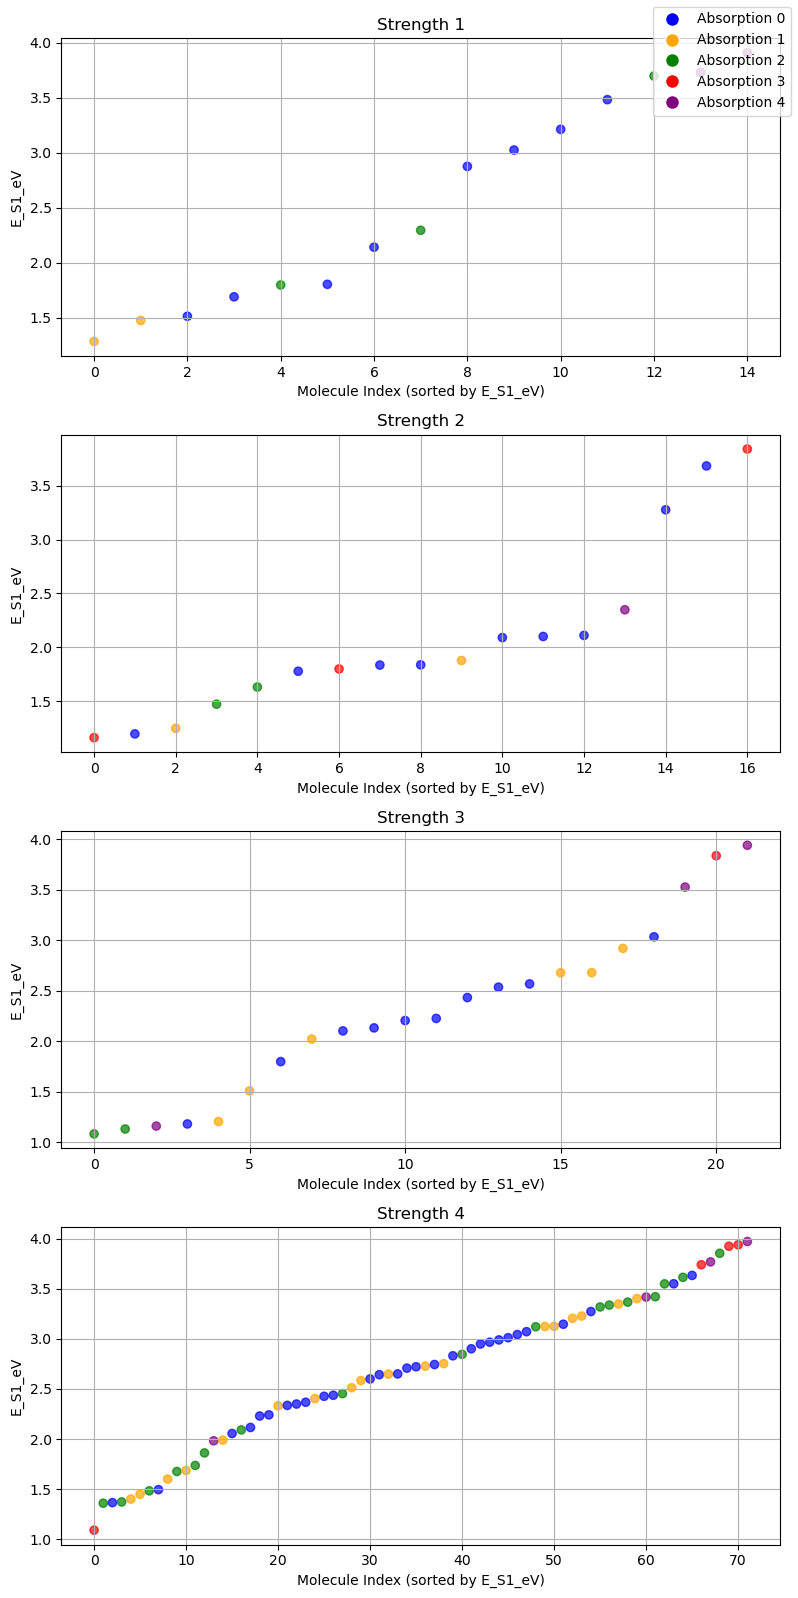

In [21]:
# for each strength value 1-4, plot the sorted E_S1_eV values with each absorption 1-4 as a different color
# make the plot 4x1 subplots
fig, axs = plt.subplots(4, 1, figsize=(8, 16))

absorption_colors = {0: 'blue',
    1: 'orange',
    2: 'green',
    3: 'red', 
    4: 'purple'}

for strength in range(1, 5):
    ax = axs[strength-1]
    subset = std2_df[std2_df['strength'] == strength]
    # sort by E_S1_eV
    subset = subset.sort_values(by='E_S1_eV')
    plot = ax.scatter(range(len(subset)), subset['E_S1_eV'], c=subset['absorption'].map(absorption_colors), alpha=0.7)
    ax.set_title(f'Strength {strength}')
    ax.set_xlabel('Molecule Index (sorted by E_S1_eV)')
    ax.set_ylabel('E_S1_eV')
    ax.grid(True)
# create a legend for the colors
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10) for color in absorption_colors.values()]
labels = [f'Absorption {key}' for key in absorption_colors.keys()]
fig.legend(handles, labels, loc='upper right')

plt.tight_layout()
plt.show()
    



# td-dft

In [27]:
td_dft_df = pd.read_csv('results/downselection/td-dft/VEE_wb97x-D3.csv')
# join std2_df absorption and strength columns to td_dft_df on smiles
td_dft_df = td_dft_df.merge(std2_df[['smiles', 'strength', 'absorption']], on='smiles', how='left')

cols = ['smiles', 'strength', 'absorption', 'E_S1_SOC(eV)', 'osc_S1_SOC']
td_dft_df = td_dft_df[cols]
td_dft_df.head()

,smiles,strength,absorption,E_S1_SOC(eV),osc_S1_SOC
0,CC1=N/C(=N\c2ccc(N3c4ccccc4Sc4ccccc43)cc2)c2cc...,0,0,3.252233,1.365684
1,CCCCCC1(C)c2cc(-c3ccc(C=C(C#N)C(=O)O)cc3)ccc2-...,0,0,3.659176,2.085913
2,O=c1oc2cc3c(cc2c2c1oc1cc(N4c5ccccc5Sc5ccccc54)...,0,0,3.808260,1.592334
3,O=[N+]([O-])C(=CNc1ccc(/N=N/c2ccccc2)cc1)[N+](...,0,0,2.781400,0.118839
4,O=Cc1ccc2c(c1)C(=O)c1cc(N3CCCCC3)ccc1-2,0,1,2.787422,0.148721


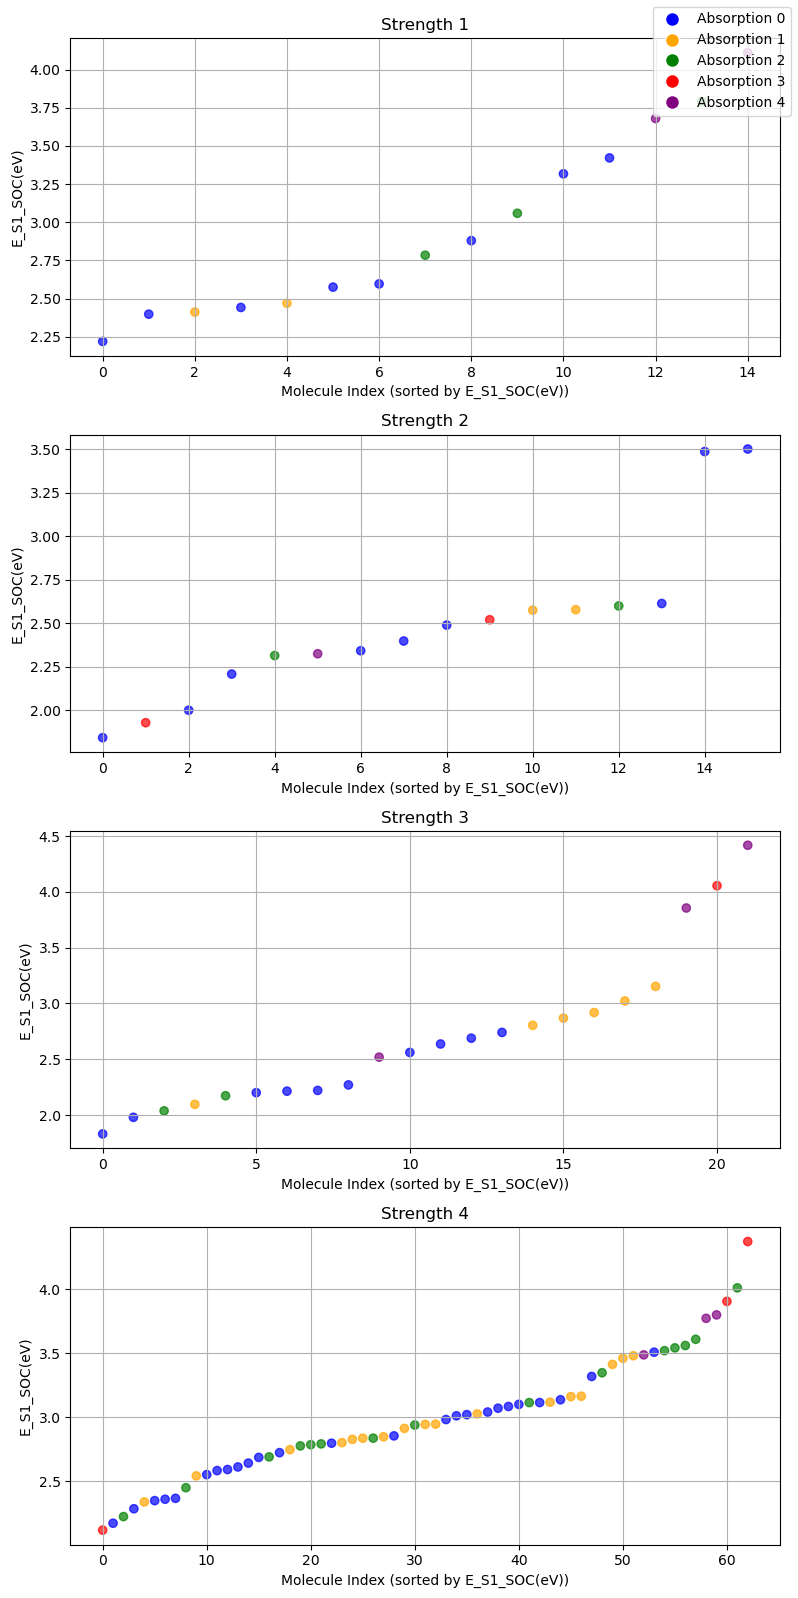

In [29]:

# for each strength value 1-4, plot the sorted E_S1_eV values with each absorption 1-4 as a different color
# make the plot 4x1 subplots
fig, axs = plt.subplots(4, 1, figsize=(8, 16))

absorption_colors = {0: 'blue',
    1: 'orange',
    2: 'green',
    3: 'red', 
    4: 'purple'}

for strength in range(1, 5):
    ax = axs[strength-1]
    subset = td_dft_df[td_dft_df['strength'] == strength]
    # sort by E_S1_eV
    subset = subset.sort_values(by='E_S1_SOC(eV)')
    plot = ax.scatter(range(len(subset)), subset['E_S1_SOC(eV)'], c=subset['absorption'].map(absorption_colors), alpha=0.7)
    ax.set_title(f'Strength {strength}')
    ax.set_xlabel('Molecule Index (sorted by E_S1_SOC(eV))')
    ax.set_ylabel('E_S1_SOC(eV)')
    ax.grid(True)
# create a legend for the colors
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10) for color in absorption_colors.values()]
labels = [f'Absorption {key}' for key in absorption_colors.keys()]
fig.legend(handles, labels, loc='upper right')

plt.tight_layout()
plt.show()
    



                                              smiles  strength  absorption  \
0  CC1=N/C(=N\c2ccc(N3c4ccccc4Sc4ccccc43)cc2)c2cc...         0           0   
1  CCCCCC1(C)c2cc(-c3ccc(C=C(C#N)C(=O)O)cc3)ccc2-...         0           0   
2  O=c1oc2cc3c(cc2c2c1oc1cc(N4c5ccccc5Sc5ccccc54)...         0           0   
3  O=[N+]([O-])C(=CNc1ccc(/N=N/c2ccccc2)cc1)[N+](...         0           0   
4            O=Cc1ccc2c(c1)C(=O)c1cc(N3CCCCC3)ccc1-2         0           1   

   E_S1_SOC(eV)  osc_S1_SOC  
0      3.252233    1.365684  
1      3.659176    2.085913  
2      3.808260    1.592334  
3      2.781400    0.118839  
4      2.787422    0.148721  


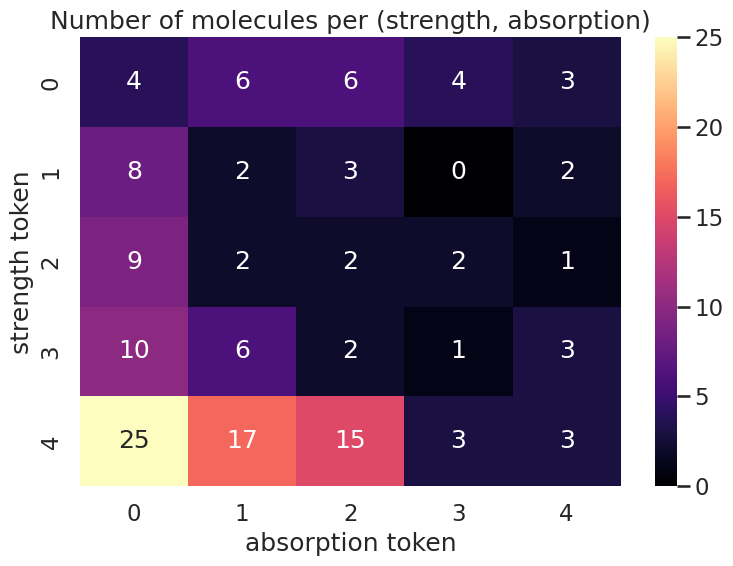

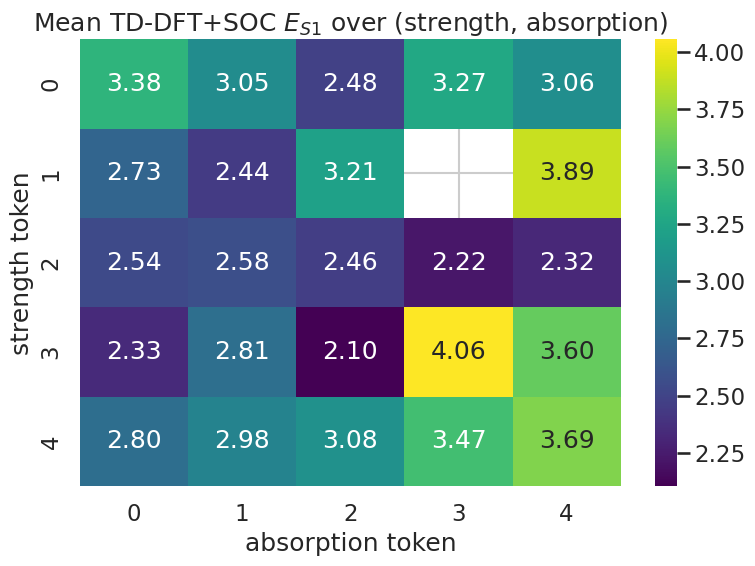

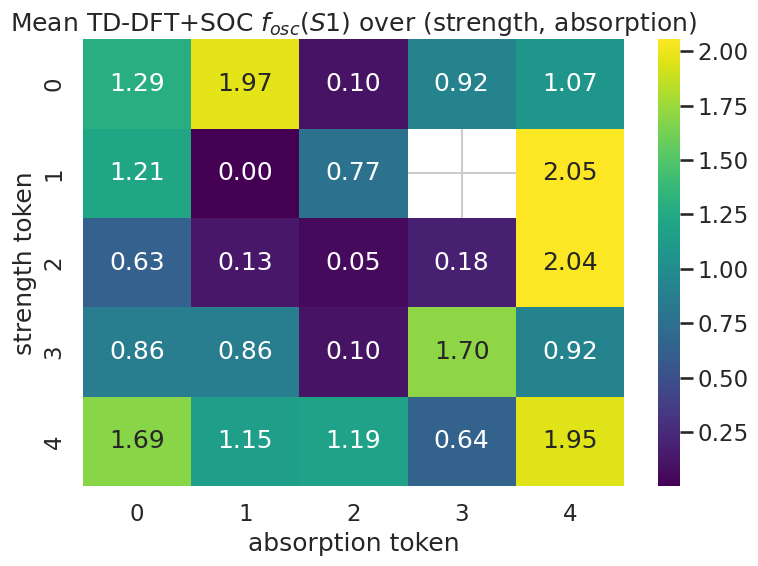

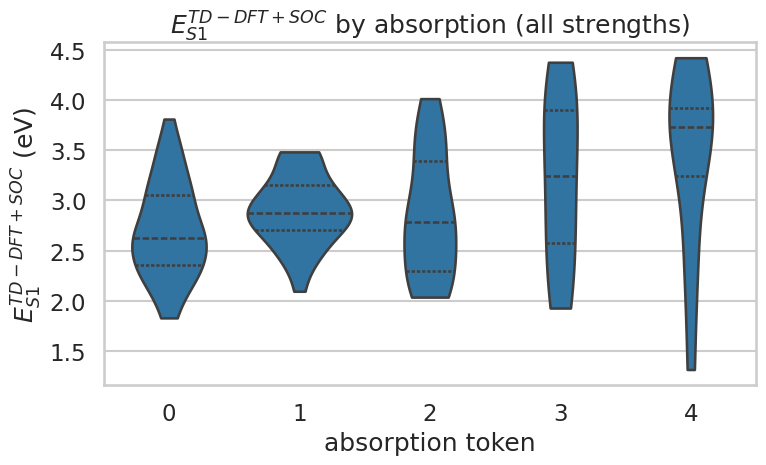

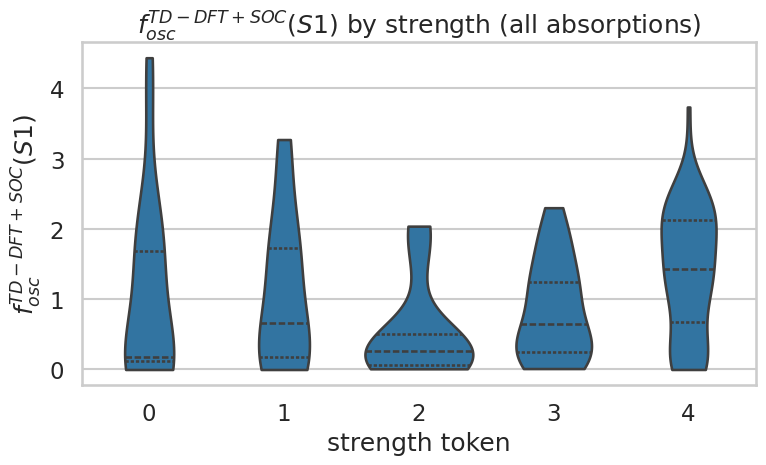

In [40]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------------------
# Basic plotting setup (no LaTeX)
# ---------------------------------------------------------------------
mpl.rcParams["text.usetex"] = False
mpl.rcParams["font.family"] = "serif"
mpl.rcParams["font.size"] = 11

sns.set_context("talk")
sns.set_style("whitegrid")

# ---------------------------------------------------------------------
# Clean up td_dft_df
# ---------------------------------------------------------------------
df = td_dft_df.copy()

# ensure numeric
for c in ["E_S1_SOC(eV)", "osc_S1_SOC", "strength", "absorption"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# drop rows missing any of the key fields
df = df.dropna(subset=["E_S1_SOC(eV)", "osc_S1_SOC", "strength", "absorption"])

# cast strength / absorption to int so they are nice discrete categories
df["strength"] = df["strength"].astype(int)
df["absorption"] = df["absorption"].astype(int)

print(df[["smiles", "strength", "absorption", "E_S1_SOC(eV)", "osc_S1_SOC"]].head())

# ---------------------------------------------------------------------
# 0) Heatmap: number of molecules per (strength, absorption)
# ---------------------------------------------------------------------
count_tbl = df.pivot_table(
    index="strength",
    columns="absorption",
    values="smiles",          # any column, we just count rows
    aggfunc="count"           # or aggfunc=len / 'size'
).fillna(0).astype(int)

plt.figure(figsize=(8, 6))
ax = sns.heatmap(count_tbl, annot=True, fmt="d", cmap="magma")
ax.set_title("Number of molecules per (strength, absorption)")
ax.set_xlabel("absorption token")
ax.set_ylabel("strength token")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# 1) Heatmap: mean E_S1_SOC(eV) over (strength, absorption)
# ---------------------------------------------------------------------
mean_E = df.pivot_table(
    index="strength",
    columns="absorption",
    values="E_S1_SOC(eV)",
    aggfunc="mean",
)

plt.figure(figsize=(8, 6))
ax = sns.heatmap(mean_E, annot=True, fmt=".2f", cmap="viridis")
ax.set_title("Mean TD-DFT+SOC $E_{S1}$ over (strength, absorption)")
ax.set_xlabel("absorption token")
ax.set_ylabel("strength token")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# 2) Heatmap: mean osc_S1_SOC over (strength, absorption)
# ---------------------------------------------------------------------
mean_f = df.pivot_table(
    index="strength",
    columns="absorption",
    values="osc_S1_SOC",
    aggfunc="mean",
)

plt.figure(figsize=(8, 6))
ax = sns.heatmap(mean_f, annot=True, fmt=".2f", cmap="viridis")
ax.set_title("Mean TD-DFT+SOC $f_{osc}(S1)$ over (strength, absorption)")
ax.set_xlabel("absorption token")
ax.set_ylabel("strength token")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# 3) Violin plot: E_S1_SOC(eV) vs absorption (all strengths pooled)
# ---------------------------------------------------------------------
plt.figure(figsize=(8, 5))
ax = sns.violinplot(
    data=df,
    x="absorption",
    y="E_S1_SOC(eV)",
    inner="quartile",
    cut=0,
)
ax.set_title("$E_{S1}^{TD-DFT+SOC}$ by absorption (all strengths)")
ax.set_xlabel("absorption token")
ax.set_ylabel("$E_{S1}^{TD-DFT+SOC}$ (eV)")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# 4) Violin plot: osc_S1_SOC vs strength (all absorptions pooled)
# ---------------------------------------------------------------------
plt.figure(figsize=(8, 5))
ax = sns.violinplot(
    data=df,
    x="strength",
    y="osc_S1_SOC",
    inner="quartile",
    cut=0,
)
ax.set_title("$f_{osc}^{TD-DFT+SOC}(S1)$ by strength (all absorptions)")
ax.set_xlabel("strength token")
ax.set_ylabel("$f_{osc}^{TD-DFT+SOC}(S1)$")
plt.tight_layout()
plt.show()


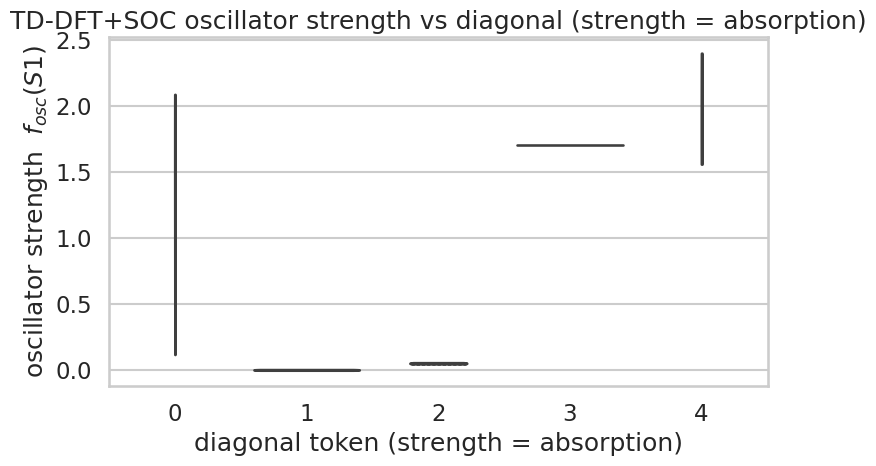

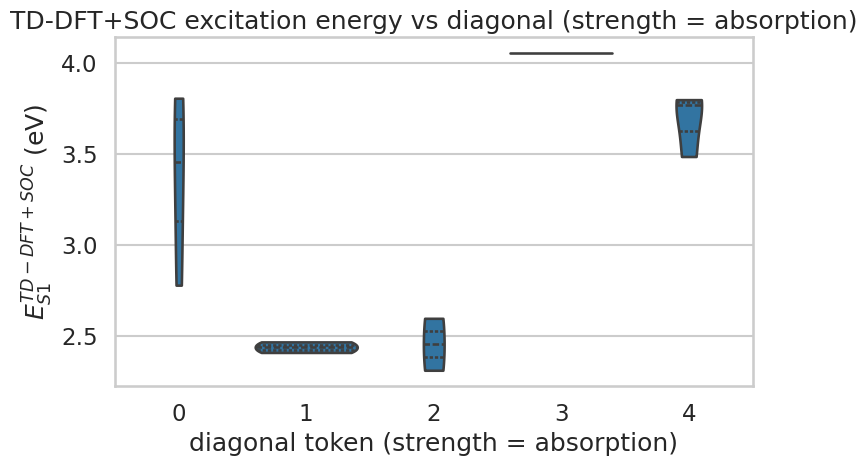

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------------------------
# Prepare df
# --------------------------------------------
df = td_dft_df.copy()

for c in ["E_S1_SOC(eV)", "osc_S1_SOC", "strength", "absorption"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna(subset=["E_S1_SOC(eV)", "osc_S1_SOC", "strength", "absorption"])
df["strength"]   = df["strength"].astype(int)
df["absorption"] = df["absorption"].astype(int)

# --------------------------------------------
# Keep only diagonal: strength == absorption
# --------------------------------------------
df_diag = df[df["strength"] == df["absorption"]].copy()

# xticks 0,1,2,3,4 (only those present)
df_diag["token"] = df_diag["strength"]   # since strength == absorption

token_order = sorted(df_diag["token"].unique())

sns.set_context("talk")
sns.set_style("whitegrid")

# ==============================================================
# 1) Oscillator strength vs diagonal token
# ==============================================================
plt.figure(figsize=(8, 5))
sns.violinplot(
    data=df_diag,
    x="token",
    y="osc_S1_SOC",
    order=token_order,
    inner="quartile",
    cut=0,
)
plt.xlabel("diagonal token (strength = absorption)")
plt.ylabel("oscillator strength  $f_{osc}(S1)$")
plt.title("TD-DFT+SOC oscillator strength vs diagonal (strength = absorption)")
plt.tight_layout()
plt.show()

# ==============================================================
# 2) Excitation energy vs diagonal token
# ==============================================================
plt.figure(figsize=(8, 5))
sns.violinplot(
    data=df_diag,
    x="token",
    y="E_S1_SOC(eV)",
    order=token_order,
    inner="quartile",
    cut=0,
)
plt.xlabel("diagonal token (strength = absorption)")
plt.ylabel("$E_{S1}^{TD-DFT+SOC}$ (eV)")
plt.title("TD-DFT+SOC excitation energy vs diagonal (strength = absorption)")
plt.tight_layout()
plt.show()


                                              smiles  strength  absorption  \
0  CC1=N/C(=N\c2ccc(N3c4ccccc4Sc4ccccc43)cc2)c2cc...         0           0   
1  CCCCCC1(C)c2cc(-c3ccc(C=C(C#N)C(=O)O)cc3)ccc2-...         0           0   
2  O=c1oc2cc3c(cc2c2c1oc1cc(N4c5ccccc5Sc5ccccc54)...         0           0   
3  O=[N+]([O-])C(=CNc1ccc(/N=N/c2ccccc2)cc1)[N+](...         0           0   
4            O=Cc1ccc2c(c1)C(=O)c1cc(N3CCCCC3)ccc1-2         0           1   

   E_S1_SOC(eV)  osc_S1_SOC  
0      3.252233    1.365684  
1      3.659176    2.085913  
2      3.808260    1.592334  
3      2.781400    0.118839  
4      2.787422    0.148721  


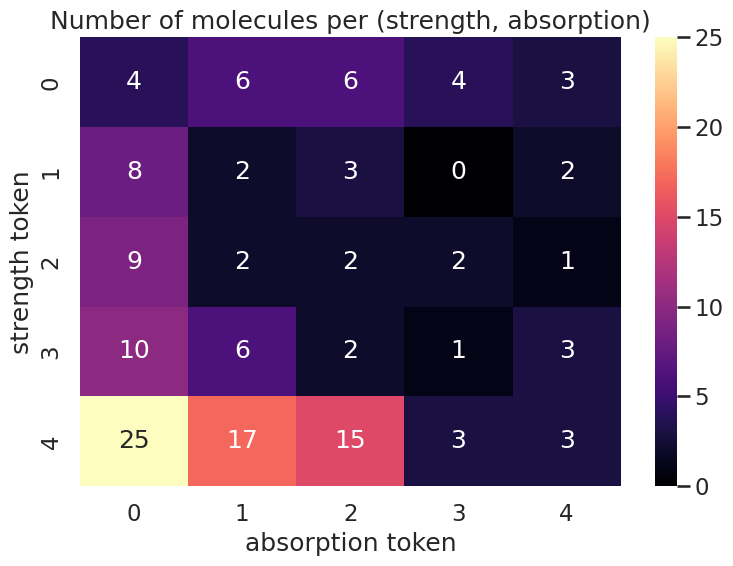

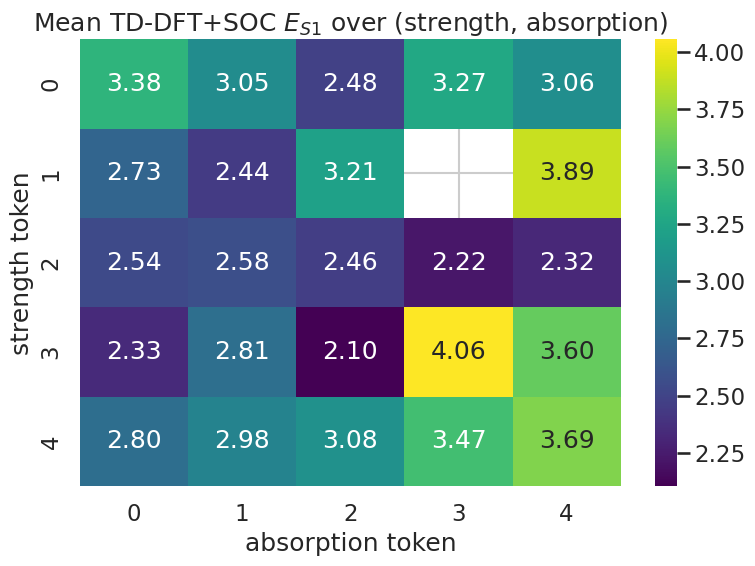

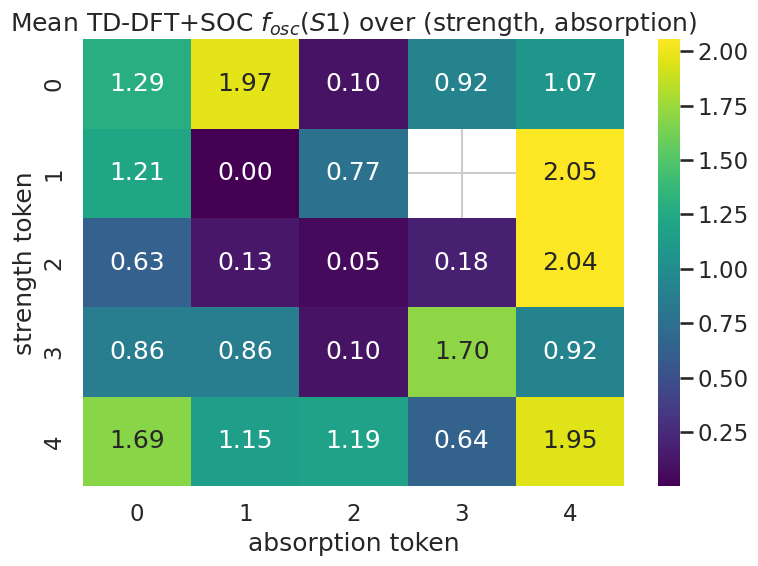

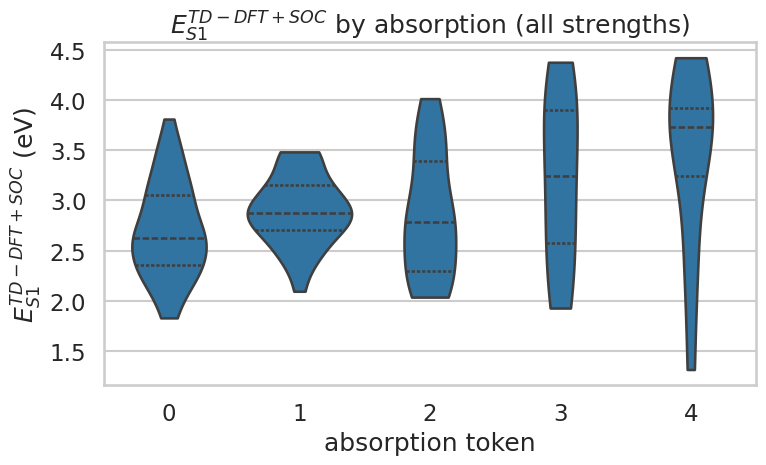

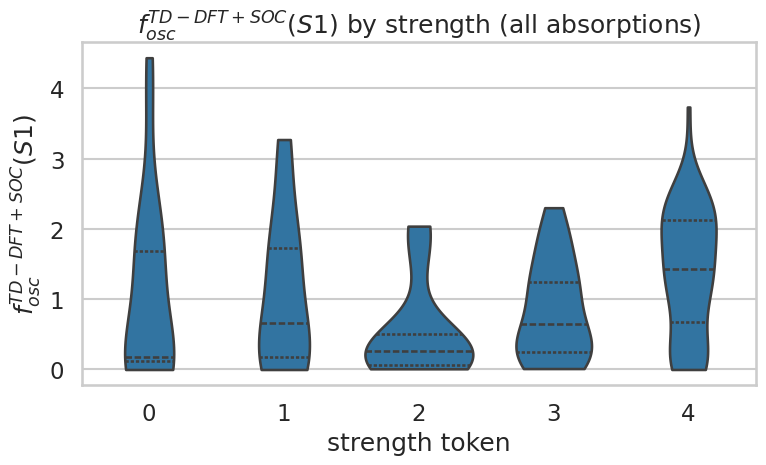

In [39]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------------------
# Basic plotting setup (no LaTeX)
# ---------------------------------------------------------------------
mpl.rcParams["text.usetex"] = False
mpl.rcParams["font.family"] = "serif"
mpl.rcParams["font.size"] = 11

sns.set_context("talk")
sns.set_style("whitegrid")

# ---------------------------------------------------------------------
# Clean up td_dft_df
# ---------------------------------------------------------------------
df = td_dft_df.copy()

# ensure numeric
for c in ["E_S1_SOC(eV)", "osc_S1_SOC", "strength", "absorption"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# drop rows missing any of the key fields
df = df.dropna(subset=["E_S1_SOC(eV)", "osc_S1_SOC", "strength", "absorption"])

# cast strength / absorption to int so they are nice discrete categories
df["strength"] = df["strength"].astype(int)
df["absorption"] = df["absorption"].astype(int)

print(df[["smiles", "strength", "absorption", "E_S1_SOC(eV)", "osc_S1_SOC"]].head())

# ---------------------------------------------------------------------
# 0) Heatmap: number of molecules per (strength, absorption)
# ---------------------------------------------------------------------
count_tbl = df.pivot_table(
    index="strength",
    columns="absorption",
    values="smiles",          # any column, we just count rows
    aggfunc="count"           # or aggfunc=len / 'size'
).fillna(0).astype(int)

plt.figure(figsize=(8, 6))
ax = sns.heatmap(count_tbl, annot=True, fmt="d", cmap="magma")
ax.set_title("Number of molecules per (strength, absorption)")
ax.set_xlabel("absorption token")
ax.set_ylabel("strength token")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# 1) Heatmap: mean E_S1_SOC(eV) over (strength, absorption)
# ---------------------------------------------------------------------
mean_E = df.pivot_table(
    index="strength",
    columns="absorption",
    values="E_S1_SOC(eV)",
    aggfunc="mean",
)

plt.figure(figsize=(8, 6))
ax = sns.heatmap(mean_E, annot=True, fmt=".2f", cmap="viridis")
ax.set_title("Mean TD-DFT+SOC $E_{S1}$ over (strength, absorption)")
ax.set_xlabel("absorption token")
ax.set_ylabel("strength token")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# 2) Heatmap: mean osc_S1_SOC over (strength, absorption)
# ---------------------------------------------------------------------
mean_f = df.pivot_table(
    index="strength",
    columns="absorption",
    values="osc_S1_SOC",
    aggfunc="mean",
)

plt.figure(figsize=(8, 6))
ax = sns.heatmap(mean_f, annot=True, fmt=".2f", cmap="viridis")
ax.set_title("Mean TD-DFT+SOC $f_{osc}(S1)$ over (strength, absorption)")
ax.set_xlabel("absorption token")
ax.set_ylabel("strength token")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# 3) Violin plot: E_S1_SOC(eV) vs absorption (all strengths pooled)
# ---------------------------------------------------------------------
plt.figure(figsize=(8, 5))
ax = sns.violinplot(
    data=df,
    x="absorption",
    y="E_S1_SOC(eV)",
    inner="quartile",
    cut=0,
)
ax.set_title("$E_{S1}^{TD-DFT+SOC}$ by absorption (all strengths)")
ax.set_xlabel("absorption token")
ax.set_ylabel("$E_{S1}^{TD-DFT+SOC}$ (eV)")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# 4) Violin plot: osc_S1_SOC vs strength (all absorptions pooled)
# ---------------------------------------------------------------------
plt.figure(figsize=(8, 5))
ax = sns.violinplot(
    data=df,
    x="strength",
    y="osc_S1_SOC",
    inner="quartile",
    cut=0,
)
ax.set_title("$f_{osc}^{TD-DFT+SOC}(S1)$ by strength (all absorptions)")
ax.set_xlabel("strength token")
ax.set_ylabel("$f_{osc}^{TD-DFT+SOC}(S1)$")
plt.tight_layout()
plt.show()


Number of molecules with strength = 4: 63


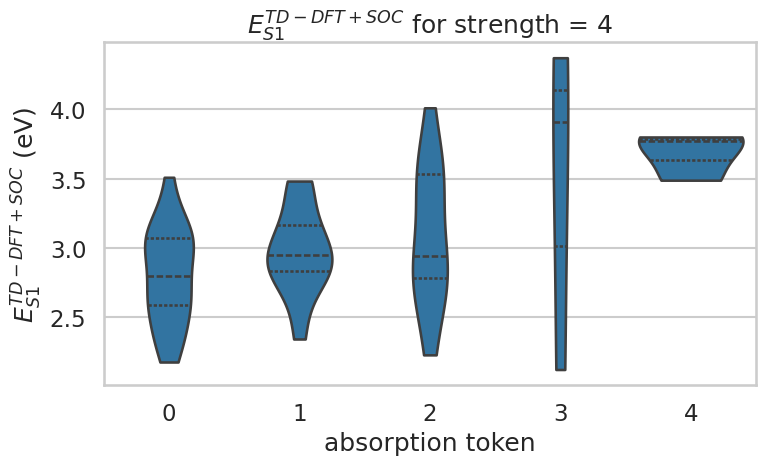

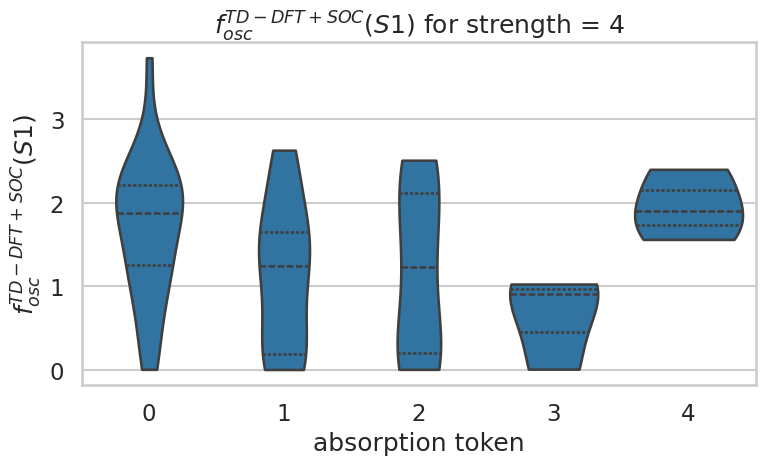

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --------------------------------------------------------
# Filter: only strength = 4
# --------------------------------------------------------
df4 = df[df["strength"] == 4].copy()

print("Number of molecules with strength = 4:", len(df4))

sns.set_context("talk")
sns.set_style("whitegrid")

# --------------------------------------------------------
# 1) Violin: E_S1_SOC(eV) vs absorption (only strength=4)
# --------------------------------------------------------
plt.figure(figsize=(8, 5))
sns.violinplot(
    data=df4,
    x="absorption",
    y="E_S1_SOC(eV)",
    inner="quartile",
    cut=0,
)
plt.title("$E_{S1}^{TD-DFT+SOC}$ for strength = 4")
plt.xlabel("absorption token")
plt.ylabel("$E_{S1}^{TD-DFT+SOC}$ (eV)")
plt.tight_layout()
plt.show()

# --------------------------------------------------------
# 2) Violin: osc_S1_SOC vs absorption (only strength=4)
# --------------------------------------------------------
plt.figure(figsize=(8, 5))
sns.violinplot(
    data=df4,
    x="absorption",
    y="osc_S1_SOC",
    inner="quartile",
    cut=0,
)
plt.title("$f_{osc}^{TD-DFT+SOC}(S1)$ for strength = 4")
plt.xlabel("absorption token")
plt.ylabel("$f_{osc}^{TD-DFT+SOC}(S1)$")
plt.tight_layout()
plt.show()
